# Barcelona Airbnb – Price Analysis
Analysis of how nightly price fluctuates across room type, minimum nights, host portfolio size, number of reviews, and district.

## 1. Load & Clean Data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120


df = pd.read_csv('listings.csv', usecols=[
    'id', 'neighbourhood_group', 'neighbourhood',
    'room_type', 'price', 'minimum_nights',
    'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365'
])

df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price', 'room_type'])
df = df[(df['price'] > 0) & (df['price'] < 5000)]   # remove extreme outliers

# Buckets
df['min_nights_bucket'] = pd.cut(
    df['minimum_nights'],
    bins=[0, 1, 3, 7, 14, 30, 9999],
    labels=['1 night', '2-3 nights', '4-7 nights', '8-14 nights', '15-30 nights', '30+ nights']
)
df['reviews_bucket'] = pd.cut(
    df['number_of_reviews'],
    bins=[-1, 0, 10, 50, 100, 9999],
    labels=['No reviews', '1-10', '11-50', '51-100', '100+']
)
df['host_size_bucket'] = pd.cut(
    df['calculated_host_listings_count'],
    bins=[0, 1, 3, 10, 50, 9999],
    labels=['1 (Solo)', '2-3', '4-10', '11-50', '50+ (Agency)']
)

print(f'Učitani listinzi: {len(df):,}')
print(f'Price range:     €{df["price"].min():.0f} – €{df["price"].max():.0f}')
print(f'Average price:   €{df["price"].mean():.2f}')
print(f'Median price:    €{df["price"].median():.2f}')

Učitani listinzi: 15,258
Price range:     €9 – €4999
Average price:   €177.68
Median price:    €130.00


## 2. Summary

In [15]:
summary = df['price'].describe().rename({
    'count': 'Count', 'mean': 'Mean (€)', '50%': 'Median (€)'
}).to_frame().T.round(2)
summary = summary[['Count', 'Mean (€)', 'Median (€)']]

summary.style.format('€{:.2f}', subset=['Mean (€)', 'Median (€)']).set_caption('Overall Price Distribution')

,Count,Mean (€),Median (€)
price,15258.000000,€177.68,€130.00


## 3. Cena po tipu sobe

,Count,Mean,Median
room_type,,,
Hotel room,50,€223.94,€202.00
Entire home/apt,"10,483",€217.79,€170.00
Private room,"4,617",€88.08,€62.00
Shared room,108,€93.31,€44.50


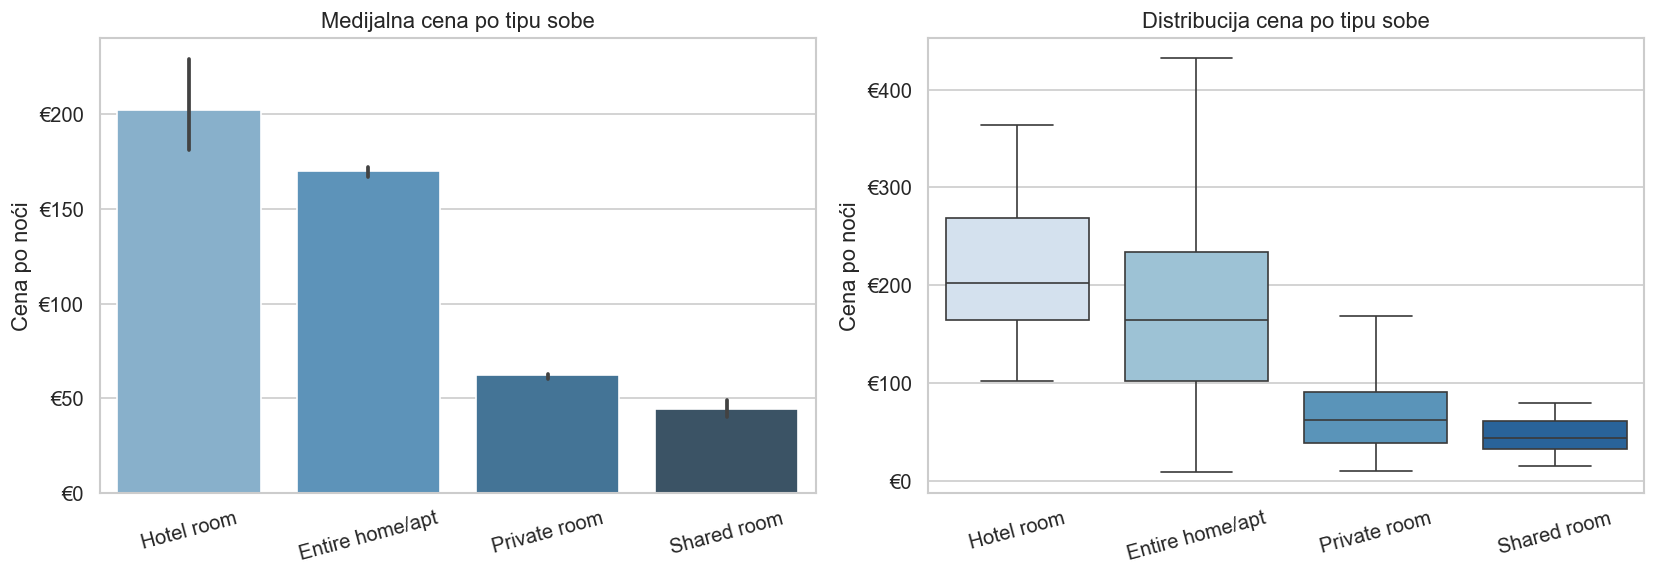

In [16]:
rt_stats = df.groupby('room_type')['price'].agg(
    Count='count', Mean='mean', Median='median'
).round(2).sort_values('Median', ascending=False)

display(rt_stats.style
    .background_gradient(subset=['Mean', 'Median'], cmap='Blues')
    .format({'Mean': '€{:.2f}', 'Median': '€{:.2f}', 'Count': '{:,}'})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = rt_stats.index.tolist()
sns.barplot(data=df, x='room_type', y='price', estimator='median',
            order=order, palette='Blues_d', ax=axes[0])
axes[0].set_title('Medijalna cena po tipu sobe')
axes[0].set_xlabel('')
axes[0].set_ylabel('Cena po noći')
axes[0].tick_params(axis='x', rotation=15)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('€%g'))

sns.boxplot(data=df[df['price'] < 600], x='room_type', y='price',
            order=order, palette='Blues', ax=axes[1], showfliers=False)
axes[1].set_title('Distribucija cena po tipu sobe')
axes[1].set_xlabel('')
axes[1].set_ylabel('Cena po noći')
axes[1].tick_params(axis='x', rotation=15)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('€%g'))

plt.tight_layout()
plt.show()

## 4. Cena po broju minimalnih noći u smeštaju

,Count,Mean,Median
min_nights_bucket,,,
1 night,"4,798",€261.06,€195.00
2-3 nights,"3,301",€203.22,€177.00
4-7 nights,868,€205.74,€183.00
8-14 nights,30,€98.87,€68.00
15-30 nights,364,€106.95,€90.00
30+ nights,"5,897",€96.17,€77.00


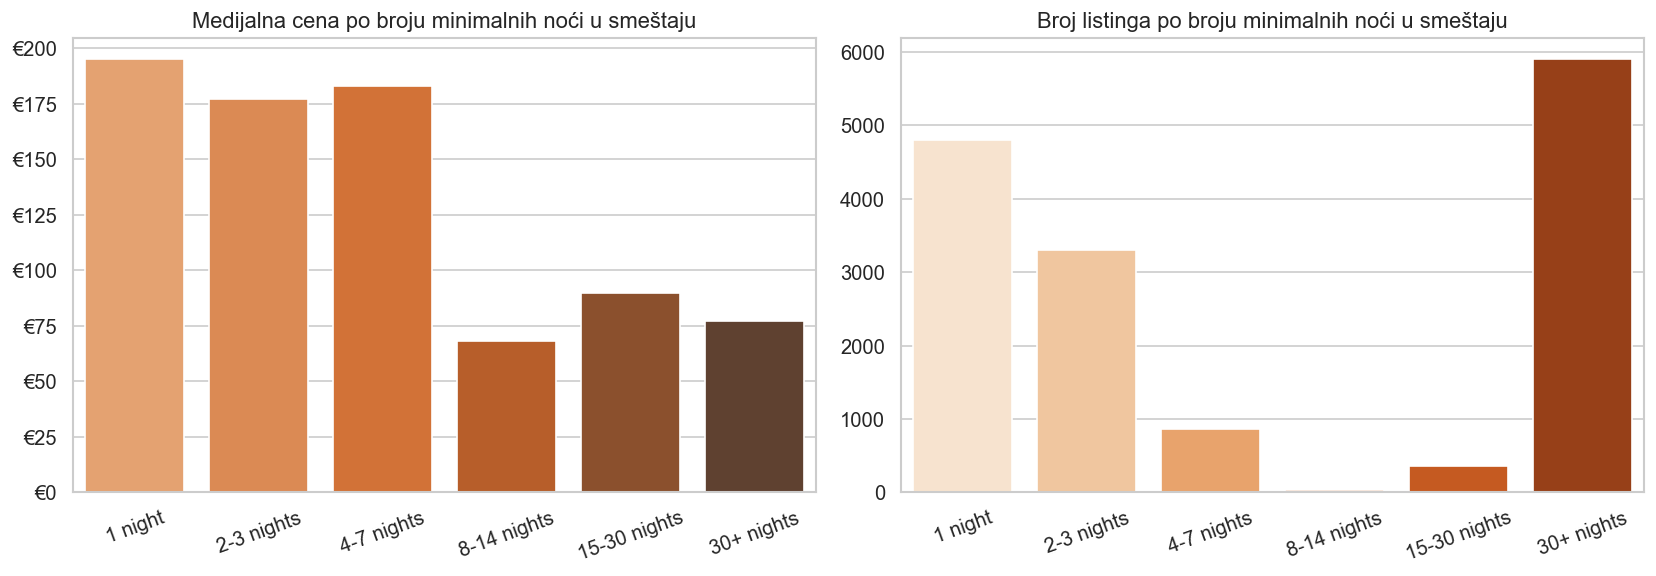

In [17]:
mn_stats = df.groupby('min_nights_bucket', observed=True)['price'].agg(
    Count='count', Mean='mean', Median='median'
).round(2)

display(mn_stats.style
    .background_gradient(subset=['Mean', 'Median'], cmap='Oranges')
    .format({'Mean': '€{:.2f}', 'Median': '€{:.2f}', 'Count': '{:,}'})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=mn_stats.reset_index(), x='min_nights_bucket', y='Median',
            palette='Oranges_d', ax=axes[0])
axes[0].set_title('Medijalna cena po broju minimalnih noći u smeštaju')
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].tick_params(axis='x', rotation=20)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('€%g'))

sns.barplot(data=mn_stats.reset_index(), x='min_nights_bucket', y='Count',
            palette='Oranges', ax=axes[1])
axes[1].set_title('Broj listinga po broju minimalnih noći u smeštaju')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 5. Cena po broju smeštaja istog domaćina

,Count,Mean,Median
host_size_bucket,,,
1 (Solo),"2,741",€138.42,€99.00
2-3,"2,140",€135.99,€94.00
4-10,"2,757",€190.11,€159.00
11-50,"4,010",€181.26,€151.00
50+ (Agency),"3,610",€218.73,€139.00


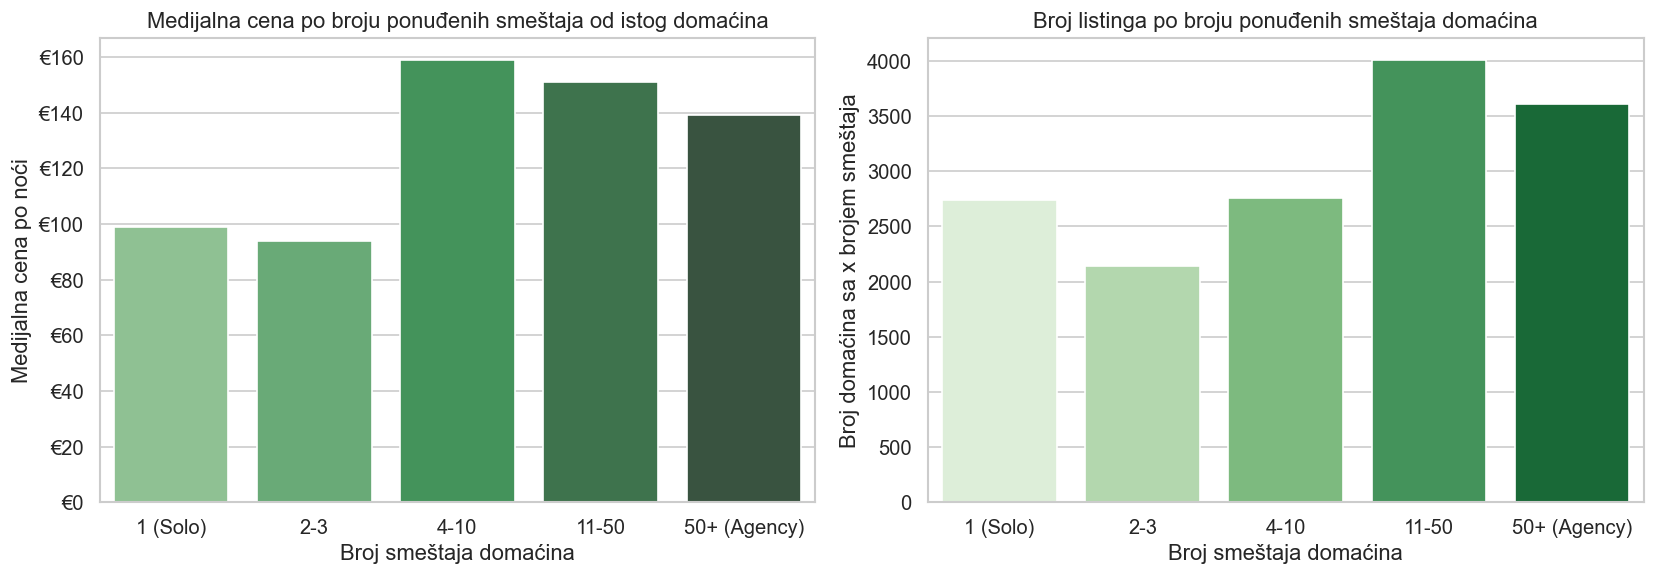

In [18]:
hs_stats = df.groupby('host_size_bucket', observed=True)['price'].agg(
    Count='count', Mean='mean', Median='median'
).round(2)

display(hs_stats.style
    .background_gradient(subset=['Mean', 'Median'], cmap='Greens')
    .format({'Mean': '€{:.2f}', 'Median': '€{:.2f}', 'Count': '{:,}'})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=hs_stats.reset_index(), x='host_size_bucket', y='Median',
            palette='Greens_d', ax=axes[0])
axes[0].set_title('Medijalna cena po broju ponuđenih smeštaja od istog domaćina')
axes[0].set_xlabel('Broj smeštaja domaćina')
axes[0].set_ylabel('Medijalna cena po noći')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('€%g'))

sns.barplot(data=hs_stats.reset_index(), x='host_size_bucket', y='Count',
            palette='Greens', ax=axes[1])
axes[1].set_title('Broj listinga po broju ponuđenih smeštaja domaćina')
axes[1].set_xlabel('Broj smeštaja domaćina')
axes[1].set_ylabel('Broj domaćina sa x brojem smeštaja')

plt.tight_layout()
plt.show()

## 6. Cena po broju recenzija

,Count,Mean,Median
reviews_bucket,,,
No reviews,"3,478",€176.82,€95.00
1-10,"4,482",€146.16,€93.00
11-50,"2,808",€172.93,€141.00
51-100,"1,525",€209.44,€196.00
100+,"2,965",€214.49,€192.00


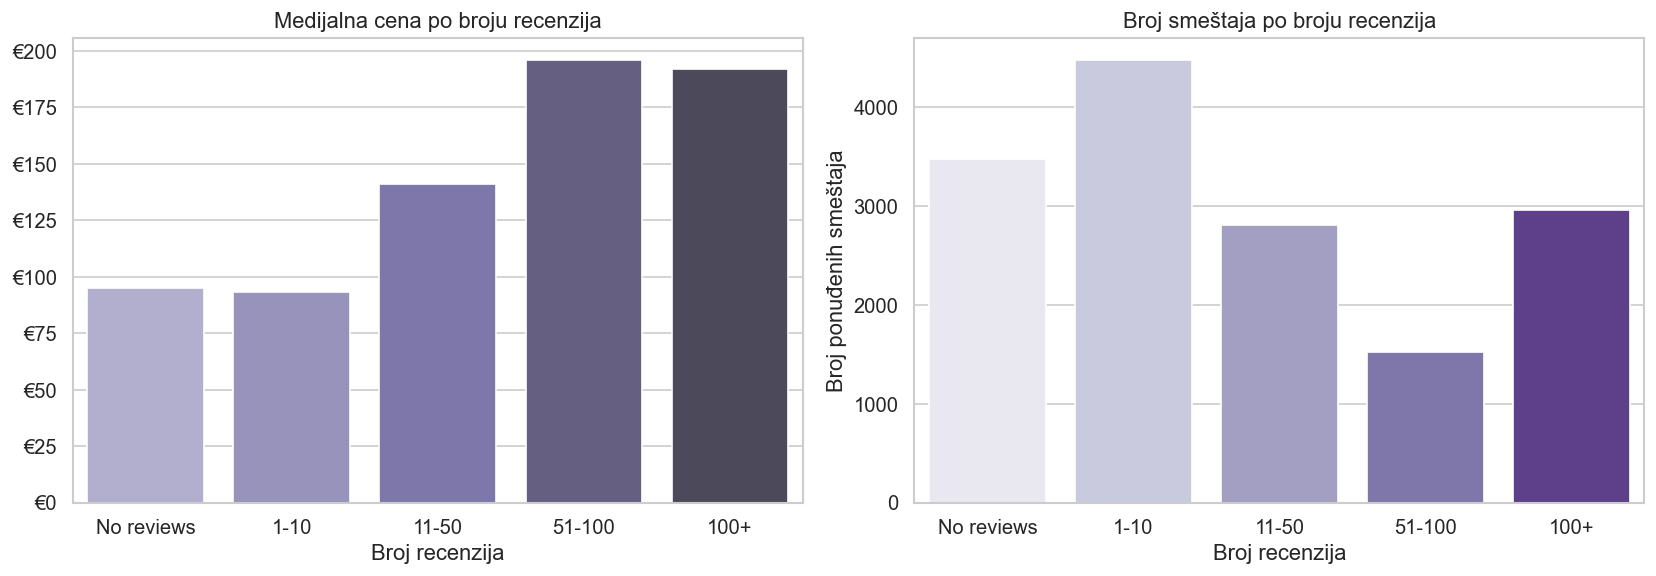

In [19]:
rv_stats = df.groupby('reviews_bucket', observed=True)['price'].agg(
    Count='count', Mean='mean', Median='median'
).round(2)

display(rv_stats.style
    .background_gradient(subset=['Mean', 'Median'], cmap='Purples')
    .format({'Mean': '€{:.2f}', 'Median': '€{:.2f}', 'Count': '{:,}'})
    
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=rv_stats.reset_index(), x='reviews_bucket', y='Median',
            palette='Purples_d', ax=axes[0])
axes[0].set_title('Medijalna cena po broju recenzija')
axes[0].set_xlabel('Broj recenzija')
axes[0].set_ylabel('')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('€%g'))

sns.barplot(data=rv_stats.reset_index(), x='reviews_bucket', y='Count',
            palette='Purples', ax=axes[1])
axes[1].set_title('Broj smeštaja po broju recenzija')
axes[1].set_xlabel('Broj recenzija')
axes[1].set_ylabel('Broj ponuđenih smeštaja')

plt.tight_layout()
plt.show()

## 7. Medijalna cena po delu grada i vrsti sobe

,Entire home/apt,Hotel room,Private room,Shared room
Ciutat Vella,€105.00,€305.50,€74.00,€63.00
Eixample,€212.00,€181.00,€64.00,€47.00
Gràcia,€166.00,€203.50,€57.00,€39.50
Horta-Guinardó,€125.00,N/A,€45.00,N/A
Les Corts,€164.00,N/A,€59.00,€53.50
Nou Barris,€175.00,N/A,€45.00,N/A
Sant Andreu,€102.00,N/A,€54.50,€53.50
Sant Martí,€166.50,€312.00,€62.00,€43.00
Sants-Montjuïc,€156.00,€176.50,€55.00,€42.00
Sarrià-Sant Gervasi,€151.50,N/A,€51.00,€22.00


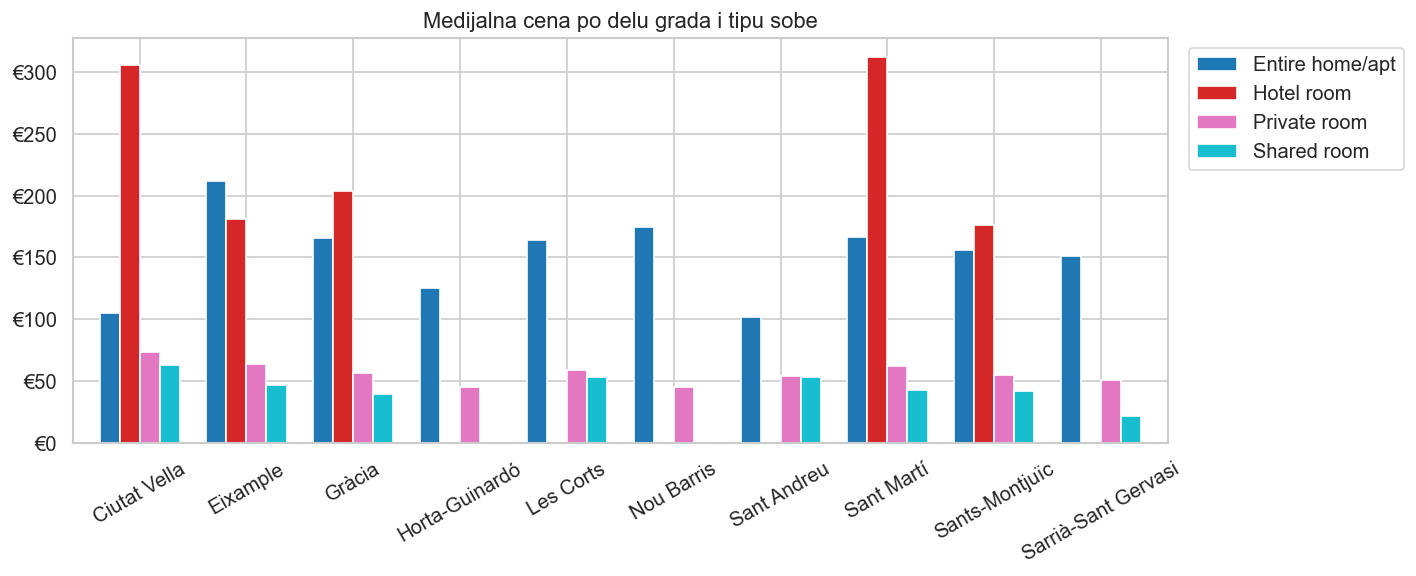

In [20]:
cross_district = df.pivot_table(
    values='price',
    index='neighbourhood_group',
    columns='room_type',
    aggfunc='median'
).round(2)
cross_district.index.name = None
cross_district.columns.name = None

display(cross_district.style
    .background_gradient(cmap='YlOrRd', axis=None)
    .format('€{:.2f}', na_rep='N/A')
)

fig, ax = plt.subplots(figsize=(12, 5))
cross_district.plot(kind='bar', ax=ax, colormap='tab10', width=0.75)
ax.set_title('Medijalna cena po delu grada i tipu sobe')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('€%g'))
ax.legend(title='', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 8. Minimalan broj noćenja i vrsta smeštaja

room_type,Entire home/apt,Hotel room,Private room,Shared room
min_nights_bucket,,,,
1 night,€223.00,€215.00,€93.00,€45.00
2-3 nights,€205.00,€191.50,€75.00,N/A
4-7 nights,€198.00,N/A,€69.50,N/A
8-14 nights,€128.00,N/A,€51.00,N/A
15-30 nights,€95.00,N/A,€40.00,€55.00
30+ nights,€99.00,N/A,€40.00,€24.00


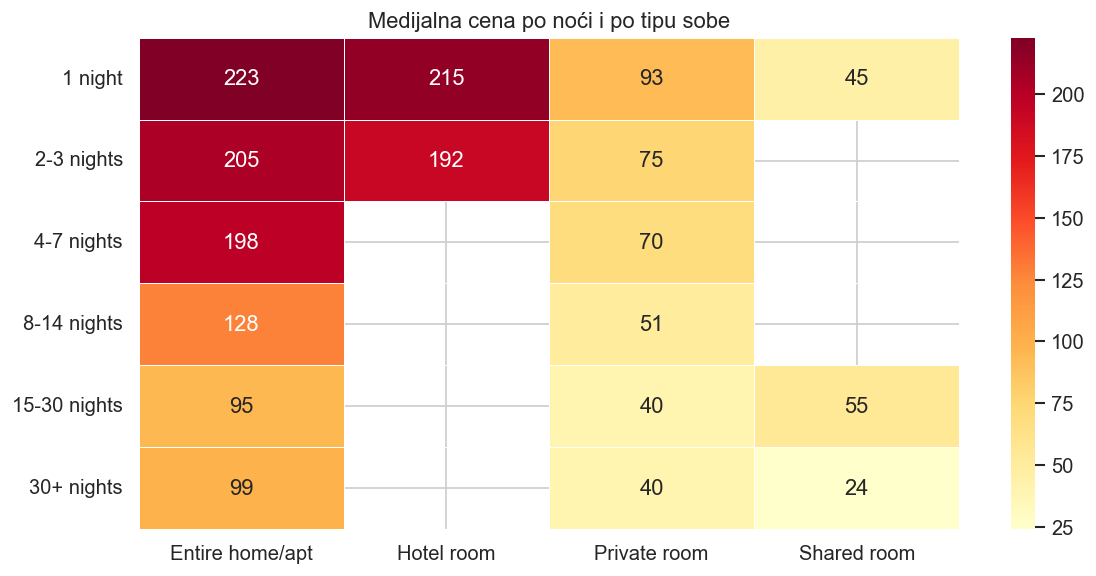

In [21]:
cross_mn_rt = df.pivot_table(
    values='price',
    index='min_nights_bucket',
    columns='room_type',
    aggfunc='median',
    observed=True
).round(2)

display(cross_mn_rt.style
    .background_gradient(cmap='RdYlGn_r', axis=None)
    .format('€{:.2f}', na_rep='N/A')
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    cross_mn_rt, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    
)
ax.set_title('Medijalna cena po noći i po tipu sobe')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [22]:
sns.heatmap(
    cross_mn_rt, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Median Price (€)'}
)
ax.set_title('Medijalna cena po noći i po tipu sobe')
ax.set_xlabel('Room Type')
ax.set_ylabel('Min Nights')
plt.tight_layout()
plt.show()

<Figure size 768x576 with 0 Axes>

## 9. Cena na osnovu recenzija i tipa smeštaja.

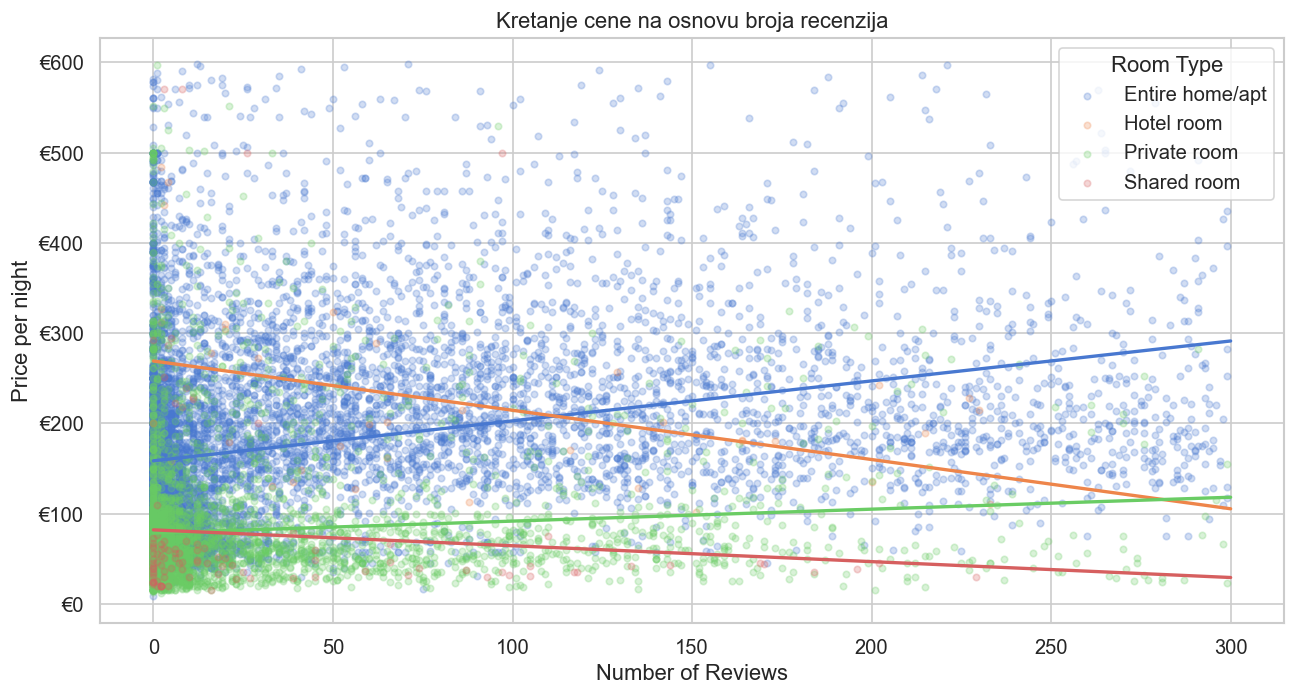

In [23]:
# Cap for readability
plot_df = df[(df['price'] < 600) & (df['number_of_reviews'] < 300)].copy()

fig, ax = plt.subplots(figsize=(11, 6))
for rt, grp in plot_df.groupby('room_type'):
    ax.scatter(grp['number_of_reviews'], grp['price'],
               alpha=0.25, s=15, label=rt)
    # trend line
    z = np.polyfit(grp['number_of_reviews'].fillna(0), grp['price'], 1)
    p = np.poly1d(z)
    xs = np.linspace(0, 300, 100)
    ax.plot(xs, p(xs), linewidth=2)

ax.set_title('Kretanje cene na osnovu broja recenzija')
ax.set_xlabel('Number of Reviews')
ax.set_ylabel('Price per night')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('€%g'))
ax.legend(title='Room Type')
plt.tight_layout()
plt.show()

## 10. Sezonalnost cene – medijalna cena dostupnih listinga po danu
Za svaki datum iz calendar.csv izračunamo medijalnu cenu

In [24]:
import matplotlib.dates as mdates


print("Loading calendar.csv ...")
cal = pd.read_csv(
    'calendar.csv',
    usecols=['listing_id', 'date', 'available'],
    dtype={'listing_id': 'int64', 'available': 'str'}
)
cal = cal[cal['available'] == 't'].copy()

listings_price = df[['id', 'price', 'room_type', 'neighbourhood_group']].copy()
cal = cal.merge(listings_price, left_on='listing_id', right_on='id', how='inner')
cal['date'] = pd.to_datetime(cal['date'])

daily = (
    cal.groupby('date')['price']
    .median()
    .reset_index()
    .rename(columns={'price': 'median_price'})
    .sort_values('date')
)
daily['rolling_7d'] = daily['median_price'].rolling(7, center=True).mean()

daily.head(10)

Loading calendar.csv ...


,date,median_price,rolling_7d
0,2025-09-14,94.0,NaN
1,2025-09-15,170.0,NaN
2,2025-09-16,150.0,NaN
3,2025-09-17,148.0,139.142857
4,2025-09-18,138.0,148.142857
5,2025-09-19,137.0,146.571429
6,2025-09-20,137.0,147.857143
7,2025-09-21,157.0,148.571429
8,2025-09-22,159.0,150.000000
9,2025-09-23,159.0,149.571429


Tanka plava linija je medijana koja se dosta pomera a debela plava linija je medijana ali prosek za 7 dana, kako bi se linija manje pomerala.

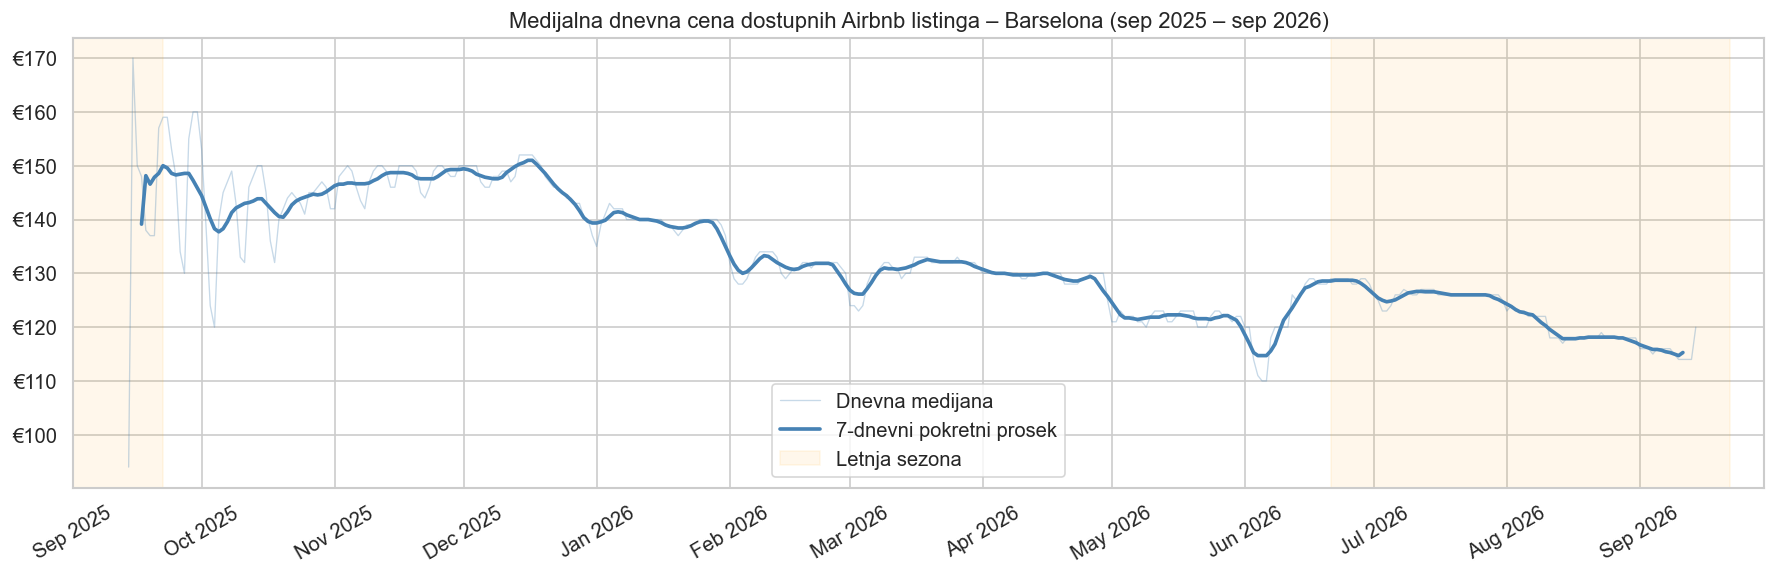

In [25]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(daily['date'], daily['median_price'],
        color='steelblue', alpha=0.3, linewidth=0.8, label='Dnevna medijana')

ax.plot(daily['date'], daily['rolling_7d'],
        color='steelblue', linewidth=2.2, label='7-dnevni pokretni prosek')

# Bojimo leto
for year in daily['date'].dt.year.unique():
    ax.axvspan(pd.Timestamp(f'{year}-06-21'), pd.Timestamp(f'{year}-09-22'),
               alpha=0.08, color='orange', label='Letnja sezona' if year == daily['date'].dt.year.min() else '')

ax.set_xlim(pd.Timestamp('2025-09-01'), pd.Timestamp('2026-09-30'))

ax.set_title('Medijalna dnevna cena dostupnih Airbnb listinga – Barselona (sep 2025 – sep 2026)')
ax.set_xlabel('')
ax.set_ylabel('')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('€%g'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

## 12. SARIMA model – fitovanje i prognoza

Koristimo (1,1,1) i (1,1,1,7), prvi deo je Non-Seasonal a drugi je Seasonal. 

(SARIMA (p, d, q)(P, D, Q, s))

7 je seasonal period, odnosno 7 dana (weekly ciklus).

Ispod vidimo da je Seasonal Naive model precizniji od SARIMA (gleda 7 prethodni dana ali bez dodatnih parametara, kao SARIMA).

Train: 2025-09-14 → 2026-07-02 (292 dana)
Test:  2026-07-03 → 2026-09-14 (74 dana)

Fitting SARIMA(1,1,1)(1,1,1,7) ...
Done.


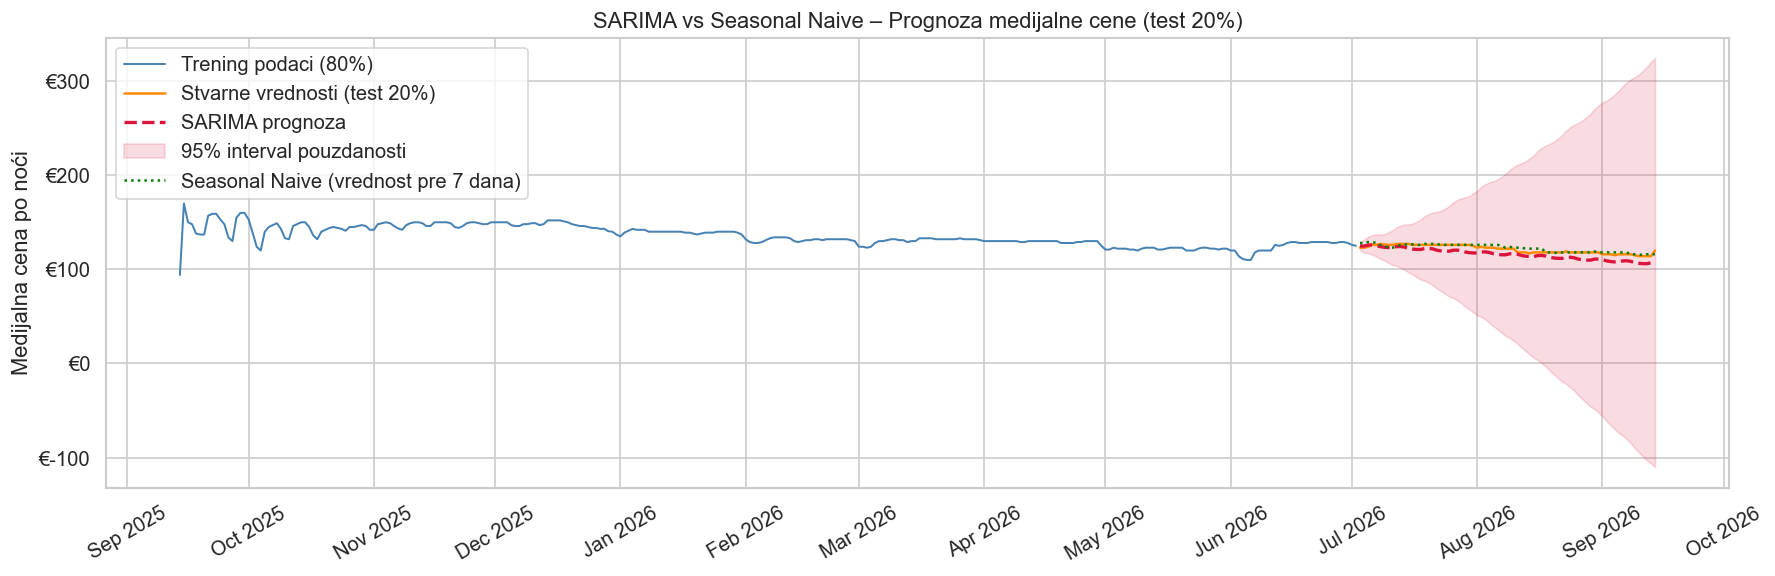

Model                       MAE       RMSE
------------------------------------------
SARIMA(1,1,1)(1,1,1,7)      €5.46      €5.87
Seasonal Naive            €1.69      €2.33


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

ts = daily.set_index('date')['median_price']

split = int(len(ts) * 0.8)
train = ts[:split]
test  = ts[split:]

print(f"Train: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} dana)")
print(f"Test:  {test.index[0].date()} → {test.index[-1].date()} ({len(test)} dana)")

naive = ts.shift(7)[split:]

print("\nFitting SARIMA(1,1,1)(1,1,1,7) ...")
model = SARIMAX(train,
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 7),
                enforce_stationarity=False,
                enforce_invertibility=False)
result = model.fit(disp=False)
print("Done.")

forecast = result.get_forecast(steps=len(test))
fc_mean  = forecast.predicted_mean
fc_ci    = forecast.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(train.index, train, color='steelblue', linewidth=1.2, label='Trening podaci (80%)')
ax.plot(test.index, test, color='darkorange', linewidth=1.5, label='Stvarne vrednosti (test 20%)')
ax.plot(fc_mean.index, fc_mean, color='crimson', linewidth=2, linestyle='--', label='SARIMA prognoza')
ax.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                color='crimson', alpha=0.15, label='95% interval pouzdanosti')
ax.plot(naive.index, naive, color='green', linewidth=1.5, linestyle=':', label='Seasonal Naive (vrednost pre 7 dana)')

ax.set_title('SARIMA vs Seasonal Naive – Prognoza medijalne cene (test 20%)')
ax.set_xlabel('')
ax.set_ylabel('Medijalna cena po noći')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('€%g'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

mae_sarima = mean_absolute_error(test, fc_mean)
rmse_sarima = mean_squared_error(test, fc_mean) ** 0.5

mae_naive = mean_absolute_error(test.dropna(), naive.dropna())
rmse_naive = mean_squared_error(test.dropna(), naive.dropna()) ** 0.5

print(f"{'Model':<20} {'MAE':>10} {'RMSE':>10}")
print("-" * 42)
print(f"{'SARIMA(1,1,1)(1,1,1,7)':<20} {'€'+f'{mae_sarima:.2f}':>10} {'€'+f'{rmse_sarima:.2f}':>10}")
print(f"{'Seasonal Naive':<20} {'€'+f'{mae_naive:.2f}':>10} {'€'+f'{rmse_naive:.2f}':>10}")